In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
book_ml = pd.read_csv('../data/book_data_cleaned_forPowerBI.csv')

In [4]:
book_ml.head()

,product_id,title,authors,original_price,current_price,quantity,category,n_review,avg_rating,pages,manufacturer,cover_link,discount,revenue
0,74021317,Cây Cam Ngọt Của Tôi,José Mauro de Vasconcelos,108000,64800,53075,Tiểu Thuyết,11481,5.0,244,Nhà Xuất Bản Hội Nhà Văn,https://salt.tikicdn.com/ts/product/5e/18/24/2...,0.4,3439260000
1,184466860,Hành Tinh Của Một Kẻ Nghĩ Nhiều,Nguyễn Đoàn Minh Thư,86000,59900,7929,Sách tư duy - Kỹ năng sống,780,4.8,184,Nhà Xuất Bản Thế Giới,https://salt.tikicdn.com/ts/product/d7/99/24/1...,0.3,474947100
2,73787185,Những Tù Nhân Của Địa Lý,Tim Marshall,210000,126000,17896,Lĩnh vực khác,3623,4.8,430,Nhà Xuất Bản Hội Nhà Văn,https://salt.tikicdn.com/ts/product/8d/96/9e/c...,0.4,2254896000
3,52789367,Nhà Giả Kim (Tái Bản 2020),Paulo Coelho,79000,47400,24668,Tác phẩm kinh điển,5131,5.0,228,Nhà Xuất Bản Hà Nội,https://salt.tikicdn.com/ts/product/45/3b/fc/a...,0.4,1169263200
4,147920903,Một Thoáng Ta Rực Rỡ Ở Nhân Gian,Unknown,135000,81000,10000,Tiểu Thuyết,1636,4.8,304,Nhà Xuất Bản Hội Nhà Văn,https://salt.tikicdn.com/ts/product/2f/b5/4e/a...,0.4,810000000


In [5]:
comment_ml = pd.read_csv('../data/comment_cleaned.csv')

In [6]:
comment_count = comment_ml.groupby('product_id').size().reset_index(name='n_comments')

In [7]:
comment_count.head()


,product_id,n_comments
0,335337,90
1,377644,90
2,378448,90
3,381234,90
4,391045,11


In [8]:
comment_count['n_comments'].value_counts().sort_index()


n_comments
1      67
2      68
3      65
4      56
5      50
     ... 
86     20
87     25
88     49
89     97
90    317
Name: count, Length: 90, dtype: int64

ta gặp vấn đề ở đây khi merge dữ liệu vào để chuẩn bị cho ML, thì vấn đề là khi thu thập dữ liệu bị giới hạn tối đa số comment 90/sách

In [9]:
book_ml = book_ml.merge(comment_count, on='product_id', how='left')
book_ml['n_comments'] = book_ml['n_comments'].fillna(0)

In [10]:
print("✅ Đã merge thành công!")
print(f"Số sách có comment: {(book_ml['n_comments'] > 0).sum()}")
print(f"Số sách không có comment: {(book_ml['n_comments'] == 0).sum()}")
print(f"Số sách có đúng 90 comments: {(book_ml['n_comments'] == 90).sum()}")

✅ Đã merge thành công!
Số sách có comment: 1634
Số sách không có comment: 96
Số sách có đúng 90 comments: 295


# Linear Regression

### Chưa Log Revenue

In [11]:
# ====== LINEAR REGRESSION – REVENUE GỐC (KHÔNG LOG) ======

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# ====== 1. Data ======
features = ['quantity', 'n_review', 'current_price']
X = book_ml[features]
y = book_ml['revenue']  # ← KHÔNG LOG

# ====== 2. Split ======
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Kích thước tập train:", X_train.shape)
print("Kích thước tập test :", X_test.shape)

# ====== 3. Train Linear Regression ======
lr = LinearRegression()
lr.fit(X_train, y_train)
print("\n✅ Đã train xong Linear Regression!")

# ====== 4. Predict ======
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

# ====== 5. Đánh giá ======
def format_currency(v):
    return f"{v:,.0f} VND"

print("\n===== LINEAR REGRESSION – REVENUE GỐC =====")

print("\n=== TRAIN ===")
print(f"R²   : {r2_score(y_train, y_train_pred):.4f}")
print(f"MAE  : {format_currency(mean_absolute_error(y_train, y_train_pred))}")
print(f"RMSE : {format_currency(np.sqrt(mean_squared_error(y_train, y_train_pred)))}")

print("\n=== TEST ===")
print(f"R²   : {r2_score(y_test, y_test_pred):.4f}")
print(f"MAE  : {format_currency(mean_absolute_error(y_test, y_test_pred))}")
print(f"RMSE : {format_currency(np.sqrt(mean_squared_error(y_test, y_test_pred)))}")

# ====== 6. Hệ số hồi quy ======
print("\n=== HỆ SỐ HỒI QUY ===")
for feature, coef in zip(features, lr.coef_):
    print(f"{feature:15s}: {coef:15,.2f}")
print(f"{'Intercept':15s}: {lr.intercept_:15,.2f}")

Kích thước tập train: (1384, 3)
Kích thước tập test : (346, 3)

✅ Đã train xong Linear Regression!

===== LINEAR REGRESSION – REVENUE GỐC =====

=== TRAIN ===
R²   : 0.9531
MAE  : 166,095,579 VND
RMSE : 456,697,806 VND

=== TEST ===
R²   : 0.7285
MAE  : 169,739,236 VND
RMSE : 374,538,978 VND

=== HỆ SỐ HỒI QUY ===
quantity       :      110,228.82
n_review       :      -73,333.99
current_price  :        2,435.63
Intercept      : -255,402,660.19


#### Kết Luận

R² = 0.7285 

Tốt

### Log Revenue

In [12]:
# ====== 1. Import ======
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# ====== 2. Data ======
features = ['quantity', 'n_review', 'current_price']
X = book_ml[features]
y = np.log1p(book_ml['revenue'])   # LOG(REVENUE)


# ====== 3. Split ======
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Kích thước tập train:", X_train.shape)
print("Kích thước tập test :", X_test.shape)


# ====== 4. Train Linear Regression ======
lr_log = LinearRegression()
lr_log.fit(X_train, y_train)
print("\n✅ Đã train xong Linear Regression (LOG)!")


# ====== 5. Predict (LOG SCALE) ======
y_train_pred_log = lr_log.predict(X_train)
y_test_pred_log  = lr_log.predict(X_test)


# ====== 6. Đánh giá trên LOG SCALE ======
print("\n===== LINEAR REGRESSION – LOG SCALE =====")

print("\n=== TRAIN (LOG SCALE) ===")
print(f"R²   : {r2_score(y_train, y_train_pred_log):.4f}")
print(f"MAE  : {mean_absolute_error(y_train, y_train_pred_log):,.2f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_train, y_train_pred_log)):.2f}")

print("\n=== TEST (LOG SCALE) ===")
print(f"R²   : {r2_score(y_test, y_test_pred_log):.4f}")
print(f"MAE  : {mean_absolute_error(y_test, y_test_pred_log):,.2f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_test_pred_log)):.2f}")


# ====== 7. INVERSE LOG → REVENUE THẬT ======
y_train_real = np.expm1(y_train)
y_train_pred_real = np.expm1(y_train_pred_log)

y_test_real = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred_log)

def format_currency(v):
    return f"{v:,.0f} VND"

print("\n===== LINEAR REGRESSION – REAL REVENUE (SAU INVERSE LOG) =====")

print("\n=== TRAIN (REAL REVENUE) ===")
print(f"R²   : {r2_score(y_train_real, y_train_pred_real):.4f}")
print(f"MAE  : {format_currency(mean_absolute_error(y_train_real, y_train_pred_real))}")
print(f"RMSE : {format_currency(np.sqrt(mean_squared_error(y_train_real, y_train_pred_real)))}")

print("\n=== TEST (REAL REVENUE) ===")
print(f"R²   : {r2_score(y_test_real, y_test_pred_real):.4f}")
print(f"MAE  : {format_currency(mean_absolute_error(y_test_real, y_test_pred_real))}")
print(f"RMSE : {format_currency(np.sqrt(mean_squared_error(y_test_real, y_test_pred_real)))}")


# ====== 8. Hệ số hồi quy (LOG MODEL) ======
print("\n=== HỆ SỐ HỒI QUY (LOG MODEL) ===")
for feature, coef in zip(features, lr_log.coef_):
    print(f"{feature:15s}: {coef:10.4f}")
print(f"{'Intercept':15s}: {lr_log.intercept_:10.4f}")


Kích thước tập train: (1384, 3)
Kích thước tập test : (346, 3)

✅ Đã train xong Linear Regression (LOG)!

===== LINEAR REGRESSION – LOG SCALE =====

=== TRAIN (LOG SCALE) ===
R²   : 0.3692
MAE  : 1.26
RMSE : 1.63

=== TEST (LOG SCALE) ===
R²   : 0.4201
MAE  : 1.25
RMSE : 1.59

===== LINEAR REGRESSION – REAL REVENUE (SAU INVERSE LOG) =====

=== TRAIN (REAL REVENUE) ===
R²   : -93541443.1489
MAE  : 550,182,291,522 VND
RMSE : 20,400,972,976,767 VND

=== TEST (REAL REVENUE) ===
R²   : -36.0102
MAE  : 519,944,751 VND
RMSE : 4,373,204,769 VND

=== HỆ SỐ HỒI QUY (LOG MODEL) ===
quantity       :     0.0000
n_review       :     0.0015
current_price  :     0.0000
Intercept      :    16.6757


#### Kết Luận
❌ Underfitting

# Random Forest Regressor

### Chưa log Revenue

In [13]:
# ====== RANDOM FOREST – REVENUE GỐC (KHÔNG LOG) ======

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor


# ====== 1. Features & target ======
features = ['quantity', 'n_review', 'current_price']

X = book_ml[features]
y = book_ml['revenue']  # ← KHÔNG LOG


# ====== 2. Train / Test split ======
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Kích thước tập train:", X_train.shape)
print("Kích thước tập test :", X_test.shape)


# ====== 3. Train Random Forest ======
rf_raw = RandomForestRegressor(
    n_estimators=300,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_raw.fit(X_train, y_train)

# ====== 4. Predict ======
y_train_pred = rf_raw.predict(X_train)
y_test_pred  = rf_raw.predict(X_test)


# ====== 5. ĐÁNH GIÁ MÔ HÌNH ======
def format_currency(v):
    return f"{v:,.0f} VND"

print("\n===== RANDOM FOREST – REVENUE GỐC (KHÔNG LOG) =====")

print("\n=== Random Forest – TRAIN ===")
print(f"R²   : {r2_score(y_train, y_train_pred):.4f}")
print(f"MAE  : {format_currency(mean_absolute_error(y_train, y_train_pred))}")
print(f"RMSE : {format_currency(np.sqrt(mean_squared_error(y_train, y_train_pred)))}")

print("\n=== Random Forest – TEST ===")
print(f"R²   : {r2_score(y_test, y_test_pred):.4f}")
print(f"MAE  : {format_currency(mean_absolute_error(y_test, y_test_pred))}")
print(f"RMSE : {format_currency(np.sqrt(mean_squared_error(y_test, y_test_pred)))}")

Kích thước tập train: (1384, 3)
Kích thước tập test : (346, 3)

===== RANDOM FOREST – REVENUE GỐC (KHÔNG LOG) =====

=== Random Forest – TRAIN ===
R²   : 0.5037
MAE  : 81,487,149 VND
RMSE : 1,486,053,748 VND

=== Random Forest – TEST ===
R²   : -1.3453
MAE  : 89,808,561 VND
RMSE : 1,100,866,366 VND


#### Kết Luận

❌ Fail

### Log Revenue

Kích thước tập train: (1384, 3)
Kích thước tập test : (346, 3)

===== RANDOM FOREST – LOG SCALE =====

=== Random Forest – TRAIN (LOG SCALE) ===
R²   : 0.9978
MAE  : 0.04
RMSE : 0.10

=== Random Forest – TEST (LOG SCALE) ===
R²   : 0.9954
MAE  : 0.07
RMSE : 0.14

===== RANDOM FOREST – REAL REVENUE (SAU INVERSE LOG) =====

=== Random Forest – TRAIN (REAL REVENUE) ===
R²   : 0.2835
MAE  : 64,381,711 VND
RMSE : 1,785,499,097 VND

=== Random Forest – TEST (REAL REVENUE) ===
R²   : 0.9532
MAE  : 32,685,383 VND
RMSE : 155,530,328 VND


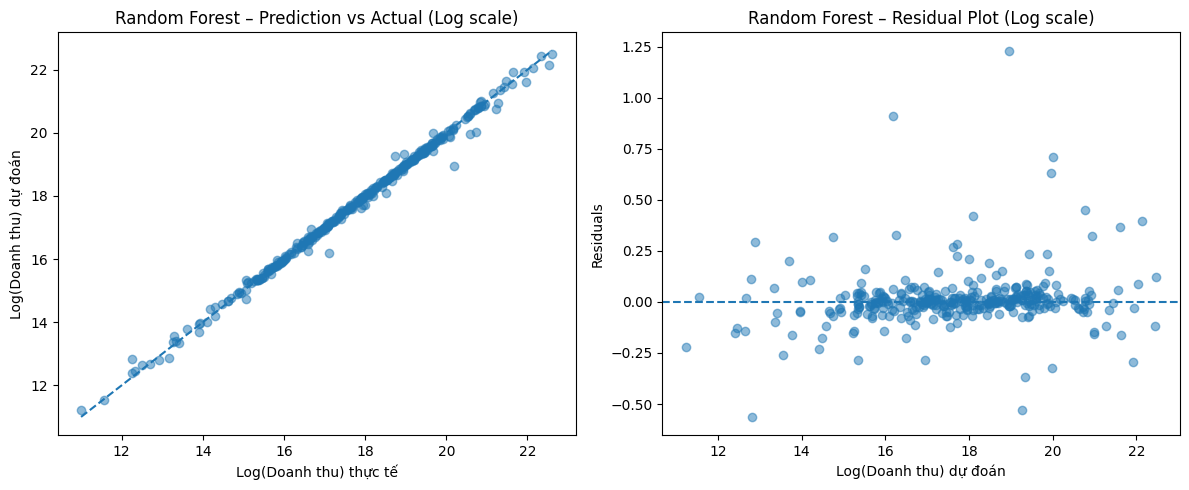

In [26]:
# ====== 1. Import ======
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor


# ====== 2. Features & target ======
features = ['quantity', 'n_review', 'current_price']

X = book_ml[features]
y = np.log1p(book_ml['revenue'])   # log(revenue)


# ====== 3. Train / Test split ======
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Kích thước tập train:", X_train.shape)
print("Kích thước tập test :", X_test.shape)


# ====== 4. Train Random Forest ======
rf_model = RandomForestRegressor(
    n_estimators=300,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# ====== 5. Predict (LOG SCALE) ======
y_train_pred_log = rf_model.predict(X_train)
y_test_pred_log  = rf_model.predict(X_test)


# ====== 6. ĐÁNH GIÁ TRÊN LOG SCALE ======
print("\n===== RANDOM FOREST – LOG SCALE =====")

print("\n=== Random Forest – TRAIN (LOG SCALE) ===")
print(f"R²   : {r2_score(y_train, y_train_pred_log):.4f}")
print(f"MAE  : {mean_absolute_error(y_train, y_train_pred_log):,.2f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_train, y_train_pred_log)):.2f}")

print("\n=== Random Forest – TEST (LOG SCALE) ===")
print(f"R²   : {r2_score(y_test, y_test_pred_log):.4f}")
print(f"MAE  : {mean_absolute_error(y_test, y_test_pred_log):,.2f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_test_pred_log)):.2f}")


# ====== 7. INVERSE LOG → REVENUE THẬT ======
y_train_real = np.expm1(y_train)
y_train_pred_real = np.expm1(y_train_pred_log)

y_test_real = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred_log)


def format_currency(v):
    return f"{v:,.0f} VND"


print("\n===== RANDOM FOREST – REAL REVENUE (SAU INVERSE LOG) =====")

print("\n=== Random Forest – TRAIN (REAL REVENUE) ===")
print(f"R²   : {r2_score(y_train_real, y_train_pred_real):.4f}")
print(f"MAE  : {format_currency(mean_absolute_error(y_train_real, y_train_pred_real))}")
print(f"RMSE : {format_currency(np.sqrt(mean_squared_error(y_train_real, y_train_pred_real)))}")

print("\n=== Random Forest – TEST (REAL REVENUE) ===")
print(f"R²   : {r2_score(y_test_real, y_test_pred_real):.4f}")
print(f"MAE  : {format_currency(mean_absolute_error(y_test_real, y_test_pred_real))}")
print(f"RMSE : {format_currency(np.sqrt(mean_squared_error(y_test_real, y_test_pred_real)))}")


# ====== 8. Plot (LOG SCALE) ======
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_test_pred_log, alpha=0.5)
min_val = min(y_test.min(), y_test_pred_log.min())
max_val = max(y_test.max(), y_test_pred_log.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')
plt.xlabel('Log(Doanh thu) thực tế')
plt.ylabel('Log(Doanh thu) dự đoán')
plt.title('Random Forest – Prediction vs Actual (Log scale)')

plt.subplot(1, 2, 2)
residuals = y_test - y_test_pred_log
plt.scatter(y_test_pred_log, residuals, alpha=0.5)
plt.axhline(y=0, linestyle='--')
plt.xlabel('Log(Doanh thu) dự đoán')
plt.ylabel('Residuals')
plt.title('Random Forest – Residual Plot (Log scale)')

plt.tight_layout()
plt.show()



#### Kết Luận

⚠️ Không ổn định là vì

TRAIN (real revenue)

R² ≈ 0.28

RMSE ≈ 1.78 tỷ

TEST (real revenue)

R² ≈ 0.95

RMSE ≈ 155 triệu

- TRAIN là dữ liệu mô hình đã học
- TEST là dữ liệu chưa từng thấy

Không có lý do gì TEST lại tốt hơn TRAIN gấp 10 lần, mặc dù mô hình có chỉ số RMSE thấp nhưng nó thiếu tính ổn định để đưa vào dự đoán doanh thu

# XGBoost

In [15]:
from xgboost import XGBRegressor


### Chưa Log Revenue

In [27]:
# ====== XGBOOST – REVENUE GỐC (KHÔNG LOG) ======

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# ====== 1. Data ======
features = ['quantity', 'n_review', 'current_price']
X = book_ml[features]
y = book_ml['revenue'] 

# ====== 2. Split ======
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Kích thước tập train:", X_train.shape)
print("Kích thước tập test :", X_test.shape)

# ====== 3. Train XGBoost ======
xgb_raw = XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)

xgb_raw.fit(X_train, y_train)

# ====== 4. Predict ======
y_train_pred = xgb_raw.predict(X_train)
y_test_pred = xgb_raw.predict(X_test)

# ====== 5. Đánh giá ======
def format_currency(v):
    return f"{v:,.0f} VND"

print("\n===== XGBOOST – REVENUE GỐC =====")

print("\n=== TRAIN ===")
print(f"R²   : {r2_score(y_train, y_train_pred):.4f}")
print(f"MAE  : {format_currency(mean_absolute_error(y_train, y_train_pred))}")
print(f"RMSE : {format_currency(np.sqrt(mean_squared_error(y_train, y_train_pred)))}")

print("\n=== TEST ===")
print(f"R²   : {r2_score(y_test, y_test_pred):.4f}")
print(f"MAE  : {format_currency(mean_absolute_error(y_test, y_test_pred))}")
print(f"RMSE : {format_currency(np.sqrt(mean_squared_error(y_test, y_test_pred)))}")

Kích thước tập train: (1384, 3)
Kích thước tập test : (346, 3)

===== XGBOOST – REVENUE GỐC =====

=== TRAIN ===
R²   : 0.9995
MAE  : 24,604,154 VND
RMSE : 47,171,312 VND

=== TEST ===
R²   : 0.9146
MAE  : 58,647,552 VND
RMSE : 210,028,494 VND


#### Kết luận

R²   : 0.9146 

bị Overfiting

### Log Revenue

Kích thước tập train: (1384, 2)
Kích thước tập test : (346, 2)

✅ Mô hình XGBoost đã được huấn luyện xong!

===== XGBOOST – LOG SCALE =====

=== XGBoost – TRAIN (LOG SCALE) ===
R²   : 0.9458
MAE  : 0.34
RMSE : 0.48

=== XGBoost – TEST (LOG SCALE) ===
R²   : 0.9183
MAE  : 0.41
RMSE : 0.60

===== XGBOOST – REAL REVENUE (SAU INVERSE LOG) =====

=== XGBoost – TRAIN (REAL REVENUE) ===
R²   : 0.1709
MAE  : 122,595,513 VND
RMSE : 1,920,713,320 VND

=== XGBoost – TEST (REAL REVENUE) ===
R²   : 0.7491
MAE  : 107,431,863 VND
RMSE : 360,041,853 VND


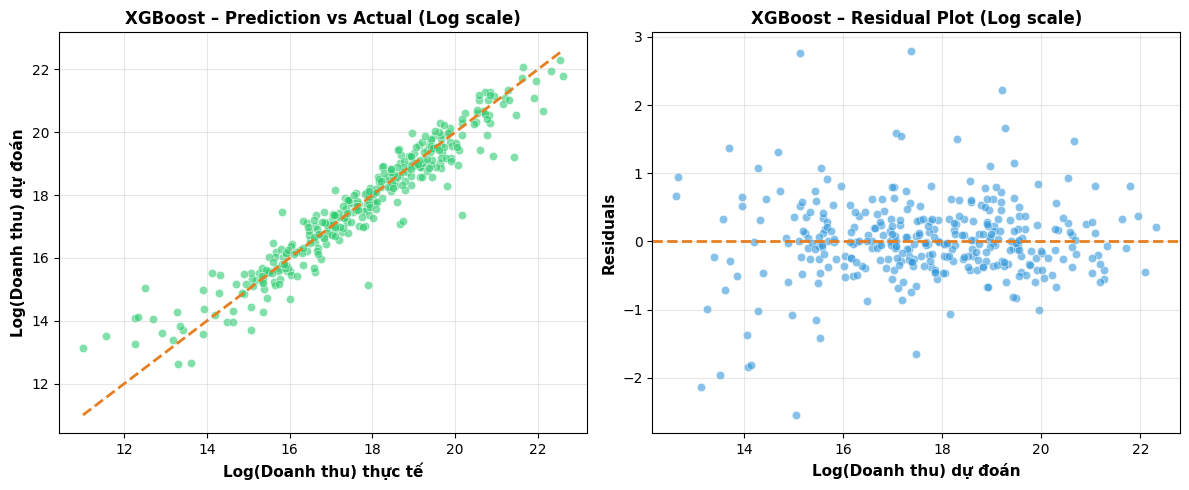

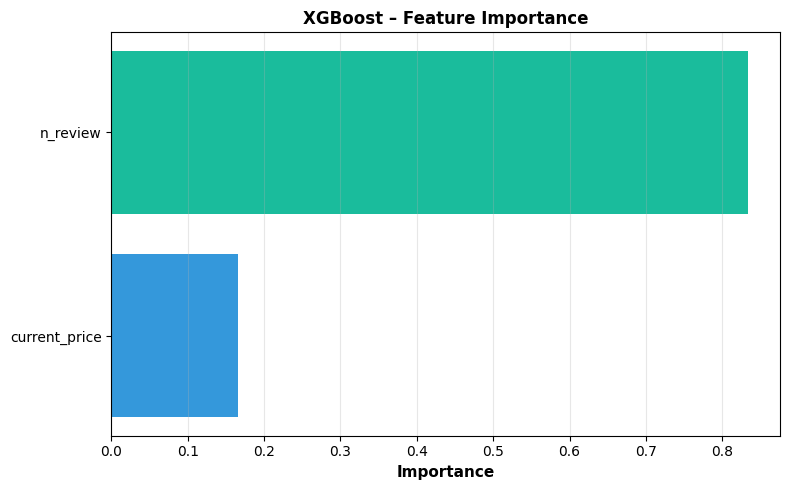


Tầm quan trọng của feature:
         Feature  Importance
0       n_review    0.834042
1  current_price    0.165958


In [38]:
# ====== 1. Import thư viện ======
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor


# ====== 2. Chọn features & target ======
features = ['n_review', 'current_price']

X = book_ml[features]
y = np.log1p(book_ml['revenue'])   # LOG(REVENUE)


# ====== 3. Chia train / test ======
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Kích thước tập train:", X_train.shape)
print("Kích thước tập test :", X_test.shape)


# ====== 4. Khởi tạo & train mô hình XGBoost ======
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)

xgb_model.fit(X_train, y_train)
print("\n✅ Mô hình XGBoost đã được huấn luyện xong!")


# ====== 5. Dự đoán (LOG SCALE) ======
y_train_pred_log = xgb_model.predict(X_train)
y_test_pred_log  = xgb_model.predict(X_test)


# ====== 6. Đánh giá trên LOG SCALE ======
print("\n===== XGBOOST – LOG SCALE =====")

print("\n=== XGBoost – TRAIN (LOG SCALE) ===")
print(f"R²   : {r2_score(y_train, y_train_pred_log):.4f}")
print(f"MAE  : {mean_absolute_error(y_train, y_train_pred_log):,.2f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_train, y_train_pred_log)):.2f}")

print("\n=== XGBoost – TEST (LOG SCALE) ===")
print(f"R²   : {r2_score(y_test, y_test_pred_log):.4f}")
print(f"MAE  : {mean_absolute_error(y_test, y_test_pred_log):,.2f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_test_pred_log)):.2f}")


# ====== 7. INVERSE LOG → ĐÁNH GIÁ TRÊN REVENUE THẬT ======
y_train_real = np.expm1(y_train)
y_train_pred_real = np.expm1(y_train_pred_log)

y_test_real = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred_log)

def format_currency(v):
    return f"{v:,.0f} VND"

print("\n===== XGBOOST – REAL REVENUE (SAU INVERSE LOG) =====")

print("\n=== XGBoost – TRAIN (REAL REVENUE) ===")
print(f"R²   : {r2_score(y_train_real, y_train_pred_real):.4f}")
print(f"MAE  : {format_currency(mean_absolute_error(y_train_real, y_train_pred_real))}")
print(f"RMSE : {format_currency(np.sqrt(mean_squared_error(y_train_real, y_train_pred_real)))}")

print("\n=== XGBoost – TEST (REAL REVENUE) ===")
print(f"R²   : {r2_score(y_test_real, y_test_pred_real):.4f}")
print(f"MAE  : {format_currency(mean_absolute_error(y_test_real, y_test_pred_real))}")
print(f"RMSE : {format_currency(np.sqrt(mean_squared_error(y_test_real, y_test_pred_real)))}")


# ====== 8. Biểu đồ Prediction vs Actual (LOG SCALE) ======
plt.figure(figsize=(12, 5))

# Subplot 1: Prediction vs Actual
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_test_pred_log, alpha=0.6, color='#2ecc71', edgecolors='white', linewidth=0.5)
min_val = min(y_test.min(), y_test_pred_log.min())
max_val = max(y_test.max(), y_test_pred_log.max())
plt.plot([min_val, max_val], [min_val, max_val], '--', color='#e67e22', linewidth=2)
plt.xlabel('Log(Doanh thu) thực tế', fontsize=11, fontweight='bold')
plt.ylabel('Log(Doanh thu) dự đoán', fontsize=11, fontweight='bold')
plt.title('XGBoost – Prediction vs Actual (Log scale)', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

# Subplot 2: Residual Plot
plt.subplot(1, 2, 2)
residuals = y_test - y_test_pred_log
plt.scatter(y_test_pred_log, residuals, alpha=0.6, color='#3498db', edgecolors='white', linewidth=0.5)
plt.axhline(y=0, linestyle='--', color='#e67e22', linewidth=2)
plt.xlabel('Log(Doanh thu) dự đoán', fontsize=11, fontweight='bold')
plt.ylabel('Residuals', fontsize=11, fontweight='bold')
plt.title('XGBoost – Residual Plot (Log scale)', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ====== 9. Feature Importance ======
importance = xgb_model.feature_importances_

fi_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values('Importance', ascending=False)

# Tạo gradient màu cho feature importance
colors = ['#1abc9c', '#3498db', '#9b59b6']  # Xanh ngọc -> Xanh dương -> Tím

plt.figure(figsize=(8, 5))
plt.barh(fi_df['Feature'], fi_df['Importance'], color=colors)
plt.gca().invert_yaxis()
plt.xlabel('Importance', fontsize=11, fontweight='bold')
plt.title('XGBoost – Feature Importance', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\nTầm quan trọng của feature:")
print(fi_df)

🔧 Đang tạo features mở rộng...
✅ Hoàn thành feature engineering!

📊 Tổng số features: 9

📝 Danh sách features:
  1. n_review
  2. current_price
  3. avg_rating
  4. discount
  5. comment_rating_mean
  6. comment_rating_std
  7. price_review_ratio
  8. rating_review_product
  9. discount_impact

✂️ Kích thước tập train: (1384, 9)
✂️ Kích thước tập test : (346, 9)

✅ Mô hình XGBoost đã được huấn luyện xong!

📈 ĐÁNH GIÁ MÔ HÌNH - LOG SCALE

🎯 TRAIN SET (LOG SCALE):
  R²   : 0.9948
  MAE  : 0.1132
  RMSE : 0.1486

🎯 TEST SET (LOG SCALE):
  R²   : 0.9351
  MAE  : 0.3885
  RMSE : 0.5309

💰 ĐÁNH GIÁ MÔ HÌNH - REAL REVENUE

🎯 TRAIN SET (REAL REVENUE):
  R²   : 0.8611
  MAE  : 45,936,687 VND
  RMSE : 786,267,578 VND

🎯 TEST SET (REAL REVENUE):
  R²   : 0.7655
  MAE  : 109,045,053 VND
  RMSE : 348,136,240 VND


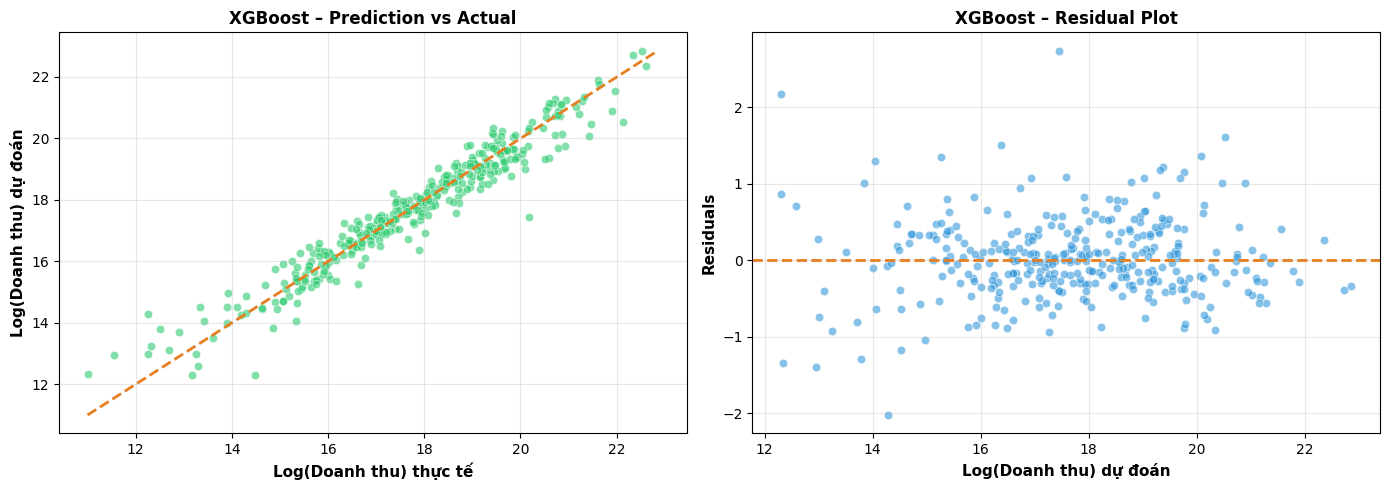

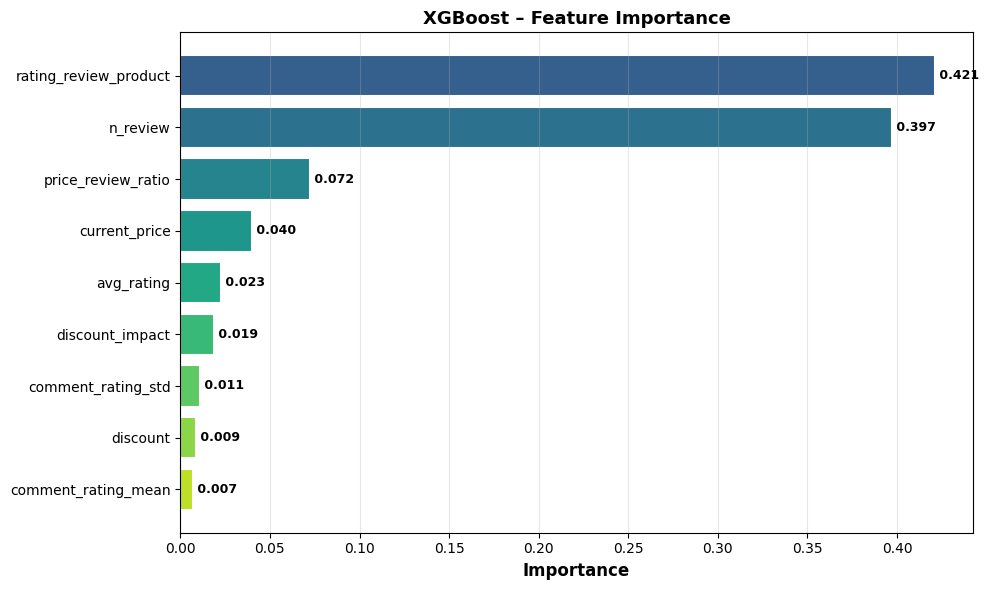


📊 TẦM QUAN TRỌNG CỦA FEATURES
  rating_review_product     : 0.4213
  n_review                  : 0.3974
  price_review_ratio        : 0.0725
  current_price             : 0.0402
  avg_rating                : 0.0227
  discount_impact           : 0.0190
  comment_rating_std        : 0.0107
  discount                  : 0.0090
  comment_rating_mean       : 0.0073


In [52]:
# ====== 1. Import thư viện ======
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor


# ====== 2. FEATURE ENGINEERING ======
print("🔧 Đang tạo features mở rộng...")

# Tính thống kê từ comments
comment_stats = comment_ml.groupby('product_id').agg({
    'rating': ['mean', 'std', 'count']
}).reset_index()

comment_stats.columns = ['product_id', 'comment_rating_mean', 'comment_rating_std', 'rating_count']
comment_stats['comment_rating_std'] = comment_stats['comment_rating_std'].fillna(0)

# Merge vào book_ml
book_ml_enhanced = book_ml.merge(comment_stats, on='product_id', how='left')
book_ml_enhanced.fillna(0, inplace=True)

# Tạo interaction features
book_ml_enhanced['price_review_ratio'] = book_ml_enhanced['current_price'] / (book_ml_enhanced['n_review'] + 1)
book_ml_enhanced['rating_review_product'] = book_ml_enhanced['avg_rating'] * book_ml_enhanced['n_review']
book_ml_enhanced['discount_impact'] = book_ml_enhanced['discount'] * book_ml_enhanced['current_price']

print("✅ Hoàn thành feature engineering!\n")


# ====== 3. Chọn features & target ======
features = [
    'n_review',                 # Số review
    'current_price',            # Giá bán
    'avg_rating',               # ⭐ Điểm TB sách (TÊN ĐÚNG)
    'discount',                 # 💰 Giảm giá (TÊN ĐÚNG)
    'comment_rating_mean',      # 📝 Điểm TB từ comments
    'comment_rating_std',       # 📊 Độ phân tán rating
    'price_review_ratio',       # 🔢 Tỷ lệ giá/review
    'rating_review_product',    # 🎯 Tích rating × review
    'discount_impact'           # 💸 Tác động giảm giá
]

print(f"📊 Tổng số features: {len(features)}")
print("\n📝 Danh sách features:")
for i, f in enumerate(features, 1):
    print(f"  {i}. {f}")

X = book_ml_enhanced[features]
y = np.log1p(book_ml_enhanced['revenue'])   # LOG(REVENUE)


# ====== 4. Chia train / test ======
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"\n✂️ Kích thước tập train: {X_train.shape}")
print(f"✂️ Kích thước tập test : {X_test.shape}")


# ====== 5. Khởi tạo & train mô hình XGBoost ======
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)

xgb_model.fit(X_train, y_train)
print("\n✅ Mô hình XGBoost đã được huấn luyện xong!")


# ====== 6. Dự đoán (LOG SCALE) ======
y_train_pred_log = xgb_model.predict(X_train)
y_test_pred_log  = xgb_model.predict(X_test)


# ====== 7. Đánh giá trên LOG SCALE ======
print("\n" + "="*60)
print("📈 ĐÁNH GIÁ MÔ HÌNH - LOG SCALE")
print("="*60)

print("\n🎯 TRAIN SET (LOG SCALE):")
print(f"  R²   : {r2_score(y_train, y_train_pred_log):.4f}")
print(f"  MAE  : {mean_absolute_error(y_train, y_train_pred_log):.4f}")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_train, y_train_pred_log)):.4f}")

print("\n🎯 TEST SET (LOG SCALE):")
print(f"  R²   : {r2_score(y_test, y_test_pred_log):.4f}")
print(f"  MAE  : {mean_absolute_error(y_test, y_test_pred_log):.4f}")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test, y_test_pred_log)):.4f}")


# ====== 8. INVERSE LOG → ĐÁNH GIÁ TRÊN REVENUE THẬT ======
y_train_real = np.expm1(y_train)
y_train_pred_real = np.expm1(y_train_pred_log)

y_test_real = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred_log)

def format_currency(v):
    return f"{v:,.0f} VND"

print("\n" + "="*60)
print("💰 ĐÁNH GIÁ MÔ HÌNH - REAL REVENUE")
print("="*60)

print("\n🎯 TRAIN SET (REAL REVENUE):")
print(f"  R²   : {r2_score(y_train_real, y_train_pred_real):.4f}")
print(f"  MAE  : {format_currency(mean_absolute_error(y_train_real, y_train_pred_real))}")
print(f"  RMSE : {format_currency(np.sqrt(mean_squared_error(y_train_real, y_train_pred_real)))}")

print("\n🎯 TEST SET (REAL REVENUE):")
print(f"  R²   : {r2_score(y_test_real, y_test_pred_real):.4f}")
print(f"  MAE  : {format_currency(mean_absolute_error(y_test_real, y_test_pred_real))}")
print(f"  RMSE : {format_currency(np.sqrt(mean_squared_error(y_test_real, y_test_pred_real)))}")


# ====== 9. Biểu đồ Prediction vs Actual ======
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_test_pred_log, alpha=0.6, color='#2ecc71', edgecolors='white', linewidth=0.5)
min_val = min(y_test.min(), y_test_pred_log.min())
max_val = max(y_test.max(), y_test_pred_log.max())
plt.plot([min_val, max_val], [min_val, max_val], '--', color='#e67e22', linewidth=2)
plt.xlabel('Log(Doanh thu) thực tế', fontsize=11, fontweight='bold')
plt.ylabel('Log(Doanh thu) dự đoán', fontsize=11, fontweight='bold')
plt.title('XGBoost – Prediction vs Actual', 
          fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
residuals = y_test - y_test_pred_log
plt.scatter(y_test_pred_log, residuals, alpha=0.6, color='#3498db', edgecolors='white', linewidth=0.5)
plt.axhline(y=0, linestyle='--', color='#e67e22', linewidth=2)
plt.xlabel('Log(Doanh thu) dự đoán', fontsize=11, fontweight='bold')
plt.ylabel('Residuals', fontsize=11, fontweight='bold')
plt.title('XGBoost – Residual Plot', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ====== 10. Feature Importance ======
importance = xgb_model.feature_importances_

fi_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values('Importance', ascending=False)

n_features = len(fi_df)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, n_features))

plt.figure(figsize=(10, 6))
bars = plt.barh(fi_df['Feature'], fi_df['Importance'], color=colors, edgecolor='white', linewidth=1.5)
plt.gca().invert_yaxis()
plt.xlabel('Importance', fontsize=12, fontweight='bold')
plt.title('XGBoost – Feature Importance', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')

for i, (bar, val) in enumerate(zip(bars, fi_df['Importance'])):
    plt.text(val, i, f' {val:.3f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("📊 TẦM QUAN TRỌNG CỦA FEATURES")
print("="*60)
for i, row in fi_df.iterrows():
    print(f"  {row['Feature']:25s} : {row['Importance']:.4f}")

## Lưu ý

- Các đặc trưng được xây dựng nhằm phản ánh hành vi mua hàng trong thực tế.
-  Nhóm biến bao gồm:
- (1) Mức độ phổ biến của sản phẩm:

     - n_review: số lượng đánh giá, đại diện cho mức độ quan tâm của người dùng.

     - rating_review_product: biến tương tác giữa avg_rating và n_review,

       kết hợp chất lượng đánh giá và độ tin cậy; rating cao nhưng ít review

       hoặc nhiều review nhưng rating thấp đều chưa đủ để thúc đẩy doanh thu.

- (2) Yếu tố giá và mức độ chấp nhận của thị trường:

     - current_price: giá bán hiện tại của sản phẩm.

     - price_review_ratio: tỷ lệ giữa giá bán và số lượng review, phản ánh mức giá tương đối so với mức độ phổ biến; giá cao đi kèm ít review thường làm giảm khả năng mua.

 (3) Chất lượng cảm nhận và yếu tố kích thích mua:

     - avg_rating: điểm đánh giá trung bình của sản phẩm.

     - comment_rating_mean, comment_rating_std: thống kê từ đánh giá chi tiết, thể hiện mức độ hài lòng và độ đồng thuận của người dùng.

     - discount: mức giảm giá niêm yết.

     - discount_impact: biến tương tác giữa discount và current_price, phản ánh giá trị giảm tuyệt đối thay vì chỉ tỷ lệ phần trăm.

 Việc kết hợp các biến này giúp mô hình học được các mối quan hệ phi tuyến

 - giữa giá, mức độ phổ biến và chất lượng đánh giá, đồng thời tránh sử dụng
 
 - trực tiếp số lượng bán để hạn chế hiện tượng rò rỉ thông tin.

## Kết Luận

✅ Ổn định nhất

In [60]:
import joblib
joblib.dump(xgb_model, "xgb_log_model_9features.pkl")
print("✅ Đã lưu model XGBoost với 9 features!")

✅ Đã lưu model XGBoost với 9 features!


# Dự đoán doanh thu sách với XGBoost

Sử dụng mô hình **XGBoost + log transform** với **9 features** đã được train với kết quả tốt nhất.

**Input:** 9 biến đầu vào
- `n_review`: Số lượng review
- `current_price`: Giá bán hiện tại (VND)
- `avg_rating`: Điểm trung bình (1-5)
- `discount`: Mức giảm giá (VND)
- `comment_rating_mean`: Điểm TB từ comments
- `comment_rating_std`: Độ phân tán rating
- `price_review_ratio`: Tỷ lệ giá/review
- `rating_review_product`: Tích rating × review
- `discount_impact`: Tác động giảm giá

In [61]:
# ================== LOAD MODEL ==================
import joblib
import numpy as np
import pandas as pd

xgb_model = joblib.load("xgb_log_model_9features.pkl")
print("✅ Đã load model xgb_log_model_9features.pkl")

# ================== HÀM DỰ ĐOÁN ==================
def predict_book_revenue(n_review, current_price, avg_rating, discount, 
                         comment_rating_mean=0, comment_rating_std=0):
    """
    Dự đoán doanh thu sách bằng XGBoost với 9 features
    
    Parameters:
    - n_review (int): Số lượng review
    - current_price (float): Giá bán hiện tại (VND)
    - avg_rating (float): Điểm trung bình (1-5)
    - discount (float): Mức giảm giá (VND)
    - comment_rating_mean (float): Điểm TB từ comments (mặc định 0)
    - comment_rating_std (float): Độ phân tán rating (mặc định 0)
    
    Returns:
    - revenue_pred (float): Doanh thu dự đoán (VND)
    """
    # Tính toán các features phụ
    price_review_ratio = current_price / (n_review + 1)
    rating_review_product = avg_rating * n_review
    discount_impact = discount * current_price
    
    # Tạo DataFrame với đúng thứ tự features
    input_data = pd.DataFrame({
        'n_review': [n_review],
        'current_price': [current_price],
        'avg_rating': [avg_rating],
        'discount': [discount],
        'comment_rating_mean': [comment_rating_mean],
        'comment_rating_std': [comment_rating_std],
        'price_review_ratio': [price_review_ratio],
        'rating_review_product': [rating_review_product],
        'discount_impact': [discount_impact]
    })
    
    # Predict log(revenue)
    log_revenue_pred = xgb_model.predict(input_data)
    
    # Convert về doanh thu thực
    revenue_pred = np.expm1(log_revenue_pred)[0]
    
    return revenue_pred

✅ Đã load model xgb_log_model_9features.pkl


In [62]:
# ================== NHẬP DỮ LIỆU TỪ NGƯỜI DÙNG ==================
print("📝 Nhập thông tin sách để dự đoán doanh thu:\n")

n_review = int(input("Số lượng review: "))
current_price = float(input("Giá bán hiện tại (VND): "))
avg_rating = float(input("Điểm trung bình (1-5): "))
discount = float(input("Mức giảm giá (VND): "))

# Optional inputs
comment_rating_mean = input("Điểm TB từ comments (Enter để bỏ qua): ")
comment_rating_mean = float(comment_rating_mean) if comment_rating_mean else 0

comment_rating_std = input("Độ phân tán rating (Enter để bỏ qua): ")
comment_rating_std = float(comment_rating_std) if comment_rating_std else 0

# Dự đoán
pred = predict_book_revenue(
    n_review=n_review,
    current_price=current_price,
    avg_rating=avg_rating,
    discount=discount,
    comment_rating_mean=comment_rating_mean,
    comment_rating_std=comment_rating_std
)

print(f"\n📈 Doanh thu dự đoán: {pred:,.0f} VND")

📝 Nhập thông tin sách để dự đoán doanh thu:



ValueError: could not convert string to float: '30%'

In [ ]:
# ================== TEST DỰ ĐOÁN ==================
pred = predict_book_revenue(
    n_review=45,
    current_price=89000,
    avg_rating=4.5,
    discount=10000,
    comment_rating_mean=4.3,
    comment_rating_std=0.5
)

print(f"📈 Doanh thu dự đoán: {pred:,.0f} VND")

TypeError: predict_book_revenue() got an unexpected keyword argument 'quantity'

In [ ]:
# ================== SCENARIO-BASED TESTING ==================

test_cases = [
    {
        "name": "Sách bán chạy",
        "n_review": 200,
        "current_price": 150000,
        "avg_rating": 4.8,
        "discount": 30000,
        "comment_rating_mean": 4.7,
        "comment_rating_std": 0.3
    },
    {
        "name": "Sách trung bình",
        "n_review": 30,
        "current_price": 120000,
        "avg_rating": 4.0,
        "discount": 15000,
        "comment_rating_mean": 4.1,
        "comment_rating_std": 0.6
    },
    {
        "name": "Sách mới ra",
        "n_review": 5,
        "current_price": 180000,
        "avg_rating": 4.5,
        "discount": 0,
        "comment_rating_mean": 4.4,
        "comment_rating_std": 0.2
    },
    {
        "name": "Sách giá rẻ",
        "n_review": 80,
        "current_price": 50000,
        "avg_rating": 3.8,
        "discount": 5000,
        "comment_rating_mean": 3.7,
        "comment_rating_std": 0.9
    },
    {
        "name": "Sách cao cấp",
        "n_review": 100,
        "current_price": 500000,
        "avg_rating": 4.9,
        "discount": 100000,
        "comment_rating_mean": 4.8,
        "comment_rating_std": 0.2
    }
]

print("=" * 120)
print("📚 DỰ ĐOÁN DOANH THU CHO NHIỀU LOẠI SÁCH (XGBoost + 9 Features)")
print("=" * 120)

results = []

for book in test_cases:
    pred = predict_book_revenue(
        n_review=book['n_review'],
        current_price=book['current_price'],
        avg_rating=book['avg_rating'],
        discount=book['discount'],
        comment_rating_mean=book['comment_rating_mean'],
        comment_rating_std=book['comment_rating_std']
    )
    
    results.append({
        'Loại sách': book['name'],
        'Reviews': book['n_review'],
        'Giá (VND)': book['current_price'],
        'Rating': book['avg_rating'],
        'Discount (VND)': book['discount'],
        'Doanh thu dự đoán (VND)': pred
    })

result_df = pd.DataFrame(results)

# Tạo bảng đẹp với formatting
styled_df = result_df.style\
    .format({
        'Giá (VND)': '{:,.0f}',
        'Discount (VND)': '{:,.0f}',
        'Doanh thu dự đoán (VND)': '{:,.0f}',
        'Rating': '{:.1f}'
    })\
    .set_properties(**{
        'text-align': 'right',
        'padding': '8px'
    })\
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2ecc71'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('border', '1px solid #ddd')]}
    ])

display(styled_df)

print("\n💡 NHẬN XÉT:")
print("   • Model dự đoán dựa trên 9 features phong phú")
print("   • Kết hợp cả yếu tố giá, rating, review, discount và các tương tác")
print("   • Không cần biết số lượng đã bán (quantity) để dự đoán")
print("   • Model học được mối quan hệ phi tuyến phức tạp giữa các biến")

📚 DỰ ĐOÁN DOANH THU CHO NHIỀU LOẠI SÁCH (XGBoost + Log Revenue)


,Loại sách,Quantity,Reviews,Giá (VND),Dự đoán (VND),Q × P (VND),Chênh lệch (%)
0,Sách bán chạy,500,200,"200,000","105,751,096","100,000,000",+5.8%
1,Sách trung bình,100,30,"120,000","16,428,350","12,000,000",+36.9%
2,Sách mới ra,20,5,"180,000","3,903,083","3,600,000",+8.4%
3,Sách giá rẻ,300,80,"50,000","19,783,932","15,000,000",+31.9%
4,Sách cao cấp,50,100,"500,000","42,718,588","25,000,000",+70.9%



💡 NHẬN XÉT:
   • Model dự đoán dựa trên quantity, n_review và current_price
   • Sách có nhiều review thường có doanh thu cao hơn công thức đơn giản
   • Model học được mối quan hệ phi tuyến giữa các biến
